# Comparison MDA vs KMeans

In [1]:
import pandas as pd
import xarray as xr
from bluemath_tk.datamining.kma import KMA
from bluemath_tk.datamining.mda import MDA
from utils.plotting import plot_variable_combinations

## Load Dataset

In [2]:
data = (
    xr.open_dataset(
        "/workspaces/BlueMath/climate_services/probabilistic/MUSCLE_Aveiro/inputs/waves_EF_daily.nc"
    )
    .rename({"swh": "Hs", "pp1d": "Tp", "mwd": "Dir"})
    .to_dataframe()
    .reset_index()
    .drop(columns=["latitude", "longitude", "time", "EF"])
)
data

,Hs,Tp,Dir
0,4.223473,12.484236,207.872380
1,3.823032,13.838945,245.494210
2,3.315165,10.994494,247.123025
3,3.660082,12.061756,268.459450
4,2.485282,11.662056,274.258270
...,...,...,...
30676,2.363185,9.037355,226.681807
30677,3.099594,12.230338,260.125392
30678,2.727585,12.531833,290.349343
30679,2.012759,11.215513,295.371523


In [3]:
num_centers = 100
dir_vars = ["Dir"]

mda = MDA(num_centers=num_centers)
nearest_centroids_idxs, nearest_centroids_df = mda.fit_predict(
    data=data,
    directional_variables=dir_vars,
)

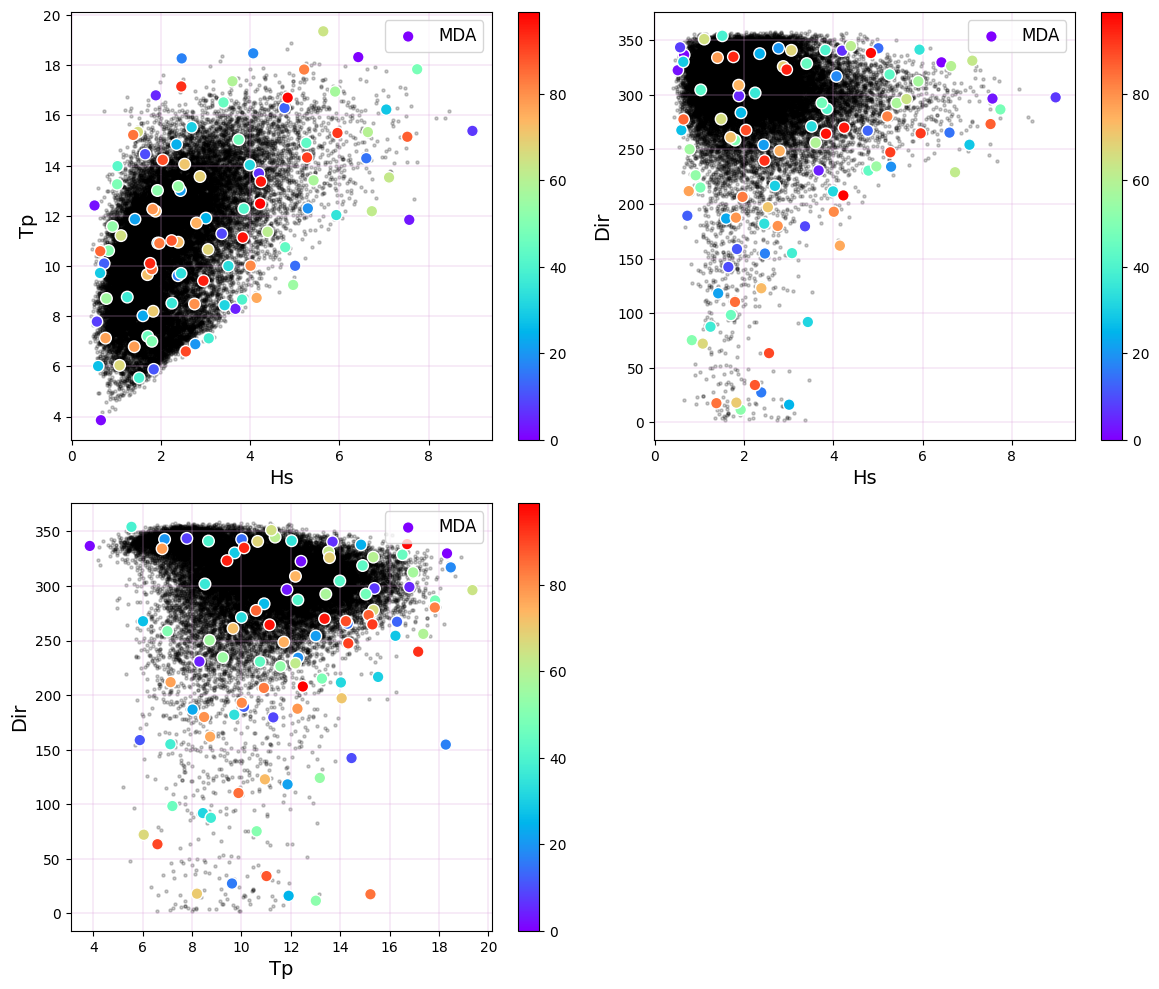

In [4]:
vars = ["Hs", "Tp", "Dir"]  # Lista de variables
sel_mda = mda.centroids[vars]  # Selección de puntos
plot_variable_combinations(mda.data, vars, mda.centroids, labels="MDA")

## KMA

In [5]:
num_centers = 100
dir_vars = ["Dir"]

kma = KMA(num_clusters=num_centers)
nearest_centroids_idxs, nearest_centroids_df = kma.fit_predict(
    data=data,
    directional_variables=dir_vars,
)

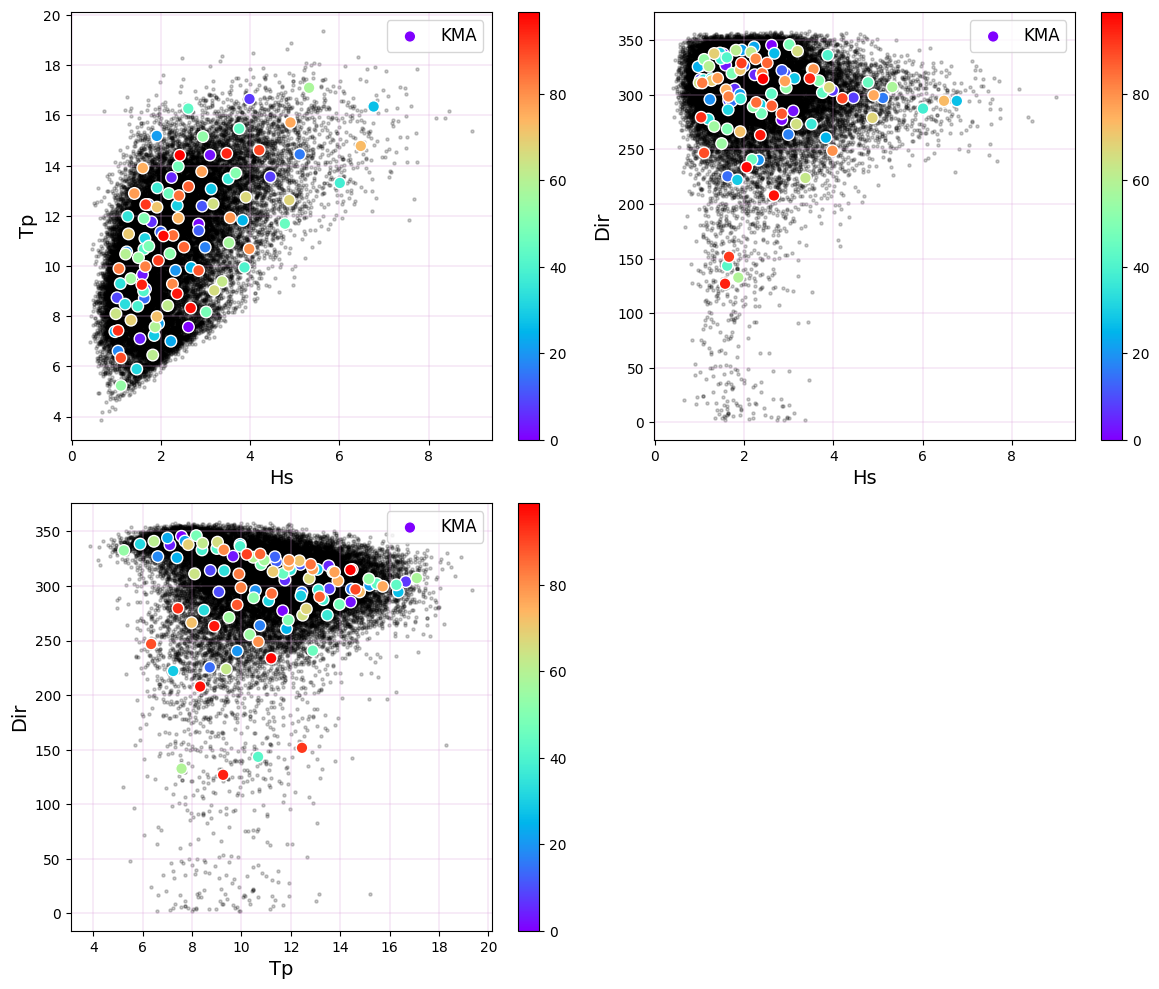

In [6]:
vars = ["Hs", "Tp", "Dir"]  # Lista de variables
plot_variable_combinations(kma.data, vars, kma.centroids, labels="KMA")

## Compare MDA vs KMA

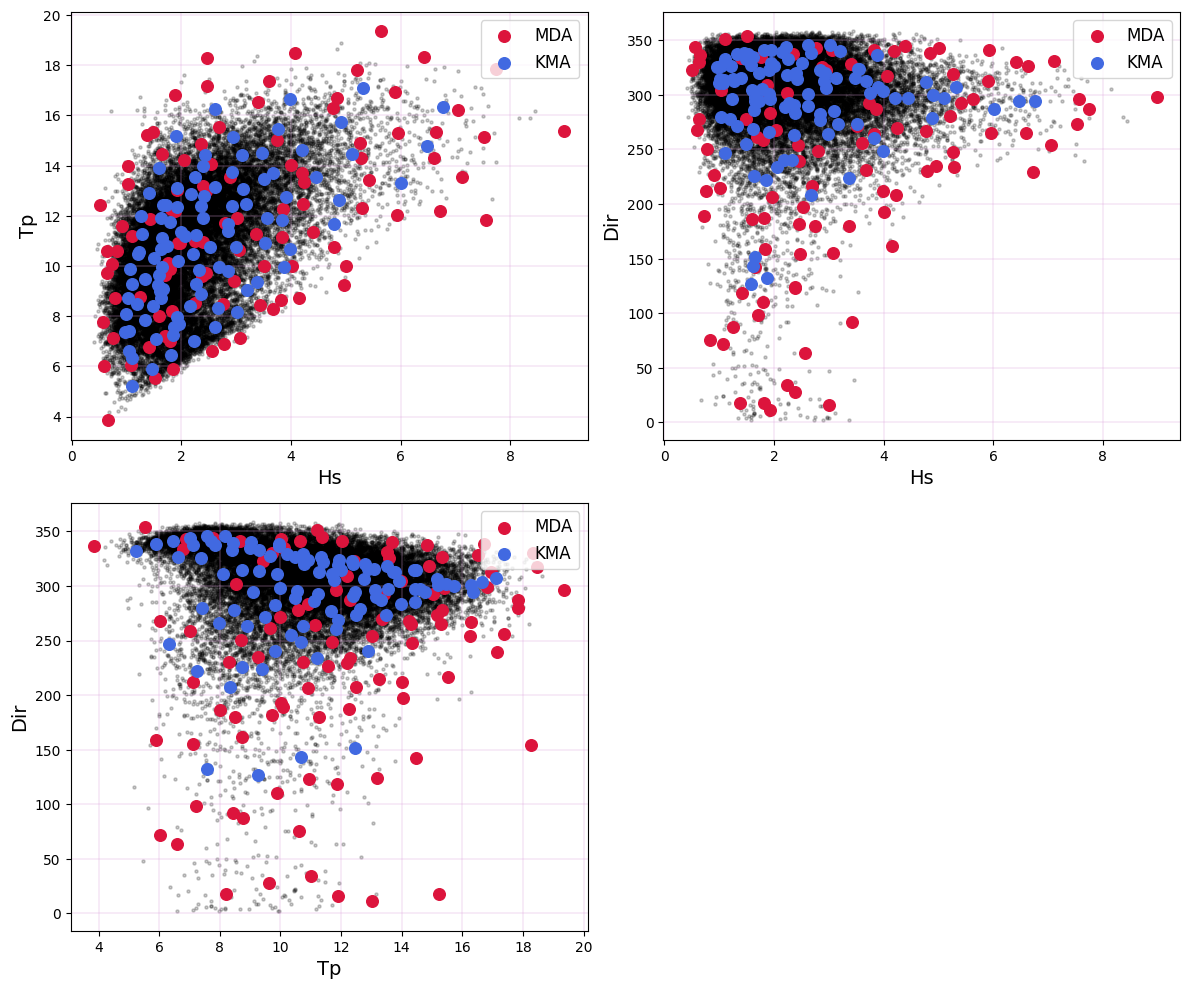

In [7]:
vars = ["Hs", "Tp", "Dir"]  # Lista de variables
sel_mda = mda.centroids[vars]  # Selección de puntos
plot_variable_combinations(
    mda.data, vars, [mda.centroids, kma.centroids], labels=["MDA", "KMA"]
)

### Predict the cluster for a given value using MDA and KMeans

In [8]:
# Generate a sample data to predict:

data_pred = pd.DataFrame({"Hs": [4, 2, 6], "Tp": [12, 10, 15], "Dir": [90, 350, 280]})

### Using MDA

In [9]:
print("\nInput data to predict:")
print(data_pred)

print("\nPredicted Cluster:")
print(mda.centroids.iloc[mda.predict(data_pred)[0]])


Input data to predict:
   Hs  Tp  Dir
0   4  12   90
1   2  10  350
2   6  15  280

Predicted Cluster:
          Hs         Tp     Dir_u     Dir_v         Dir
25  3.008505  11.908449  0.277457  0.960738   16.108470
94  1.759015  10.104100 -0.424224  0.905557  334.898443
92  5.956229  15.302169 -0.995862 -0.090873  264.786147


### Using KMeans

In [10]:
print("\nInput data to predict:")
print(data_pred)

print("\nPredicted Cluster:")
print(kma.centroids.iloc[kma.predict(data_pred)[0].kma_bmus.values])


Input data to predict:
   Hs  Tp  Dir
0   4  12   90
1   2  10  350
2   6  15  280

Predicted Cluster:
          Hs         Tp     Dir_u     Dir_v         Dir
79  3.554024  11.922829 -0.574004  0.776351  323.522215
91  1.942281  10.217229 -0.504229  0.839945  329.023102
73  6.479096  14.783860 -0.853304  0.390604  294.596136
